In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm_multiply, spsolve, norm
from pde import CartesianGrid, solve_laplace_equation
from utils import get_laplacian

We test Schrodingerization to solve a linear system.

In [2]:
def schrodingerization(A, u_0, N, L, R, T, N_t, lambda_min):
    dimension = u_0.shape[0]
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H2 = (A - np.conj(A).T) / 2j
    print("H1:", H1.toarray())
    print("H2:", H2.toarray())

    p_vals = np.linspace(L, R, N)
    v_0 = kron(u_0, np.exp(-np.abs(p_vals))).toarray().flatten() # second axis is for p

    # Write out the Hamiltonian
    # centered differences
    H = 1j * (- kron(H1, (1 / (2 * h)) * diags([np.ones(N-1), -np.ones(N-1)], offsets=[1,-1])) + 1j * kron(H2, eye(N)))
    # Solve the PDE
    v = expm_multiply(-1j * H, v_0, start=0, stop=T, num=N_t).real

    # One issue: how to recover the amplitudes? (need to take absolute value?)
    # u_recover = np.sum(np.abs(np.reshape(v, newshape=(N_t, dimension, N))[:,:,N//2:]), axis=2) * h

    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    # u_recover = np.reshape(v, newshape=(N_t, dimension, N))[:,:,p_index] * np.exp(np.abs(p_vals[p_index]))
    
    return u_recover


In [3]:
L, R = -5, 5
N = 256
h = (R - L) / (N - 1)
print(h)
T = 1
N_t = 16
u_0 = np.array([1, 3])
p_vals = np.linspace(L, R, N)

dimension = 2
A = random(dimension, dimension, density=1) - diags(np.random.uniform(low=2, high=3, size=dimension))
A = (A + A.T) / 2
print(A.toarray())
print(eigvalsh(A.toarray()))
assert np.alltrue(eigvalsh(A.toarray() <= 0))
# A = np.array([[-1, 0], [0, -1]])

u_recover = schrodingerization(A, u_0.reshape((2,1)), N, L, R, T, N_t, 0)
# v_0 = v_0.reshape(dimension, N)

0.0392156862745098
[[-1.83956027  0.55394006]
 [ 0.55394006 -2.59757212]]
[-2.8897555 -1.5473769]
Eigvals of H1: [-2.8897555 -1.5473769]
H1: [[-1.83956027  0.55394006]
 [ 0.55394006 -2.59757212]]
H2: [[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]


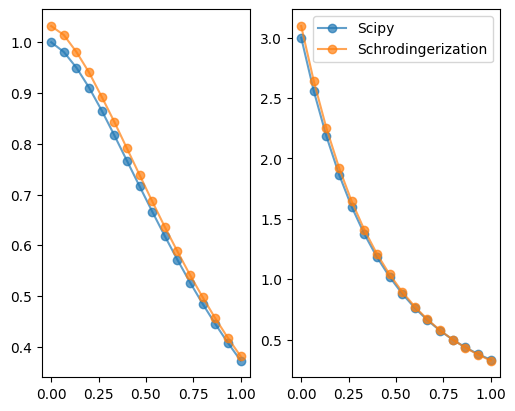

In [4]:
F = lambda t, u: A @ u

t_vals = np.linspace(0, T, N_t)
sol = solve_ivp(F, [0, T], u_0, t_eval=t_vals)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(5,4))

aspect = 0.4

for i in range(dimension):

    axs[i].plot(t_vals, sol.y[i], '-o', label="Scipy", alpha=0.7)
    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization", alpha=0.7)

plt.legend()
plt.show()

Solve a linear system via gradient flow

In [11]:
def solve_gradient_flow(A, b, x_0, N, L, R, T, N_t):
    # The gradient of the optimization problem is Ax-b, so the gradient flow ODE is x'(t) = - Ax + b.
    A_tilde = vstack([hstack([A, -b]), csc_matrix((1, A.shape[0]+1))])
    print(A_tilde.toarray())
    print("Eigvals of A_tilde: ", eigvals(A_tilde.toarray()))

    lambda_max = np.min(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
    print("Min eval:", lambda_max)
    u_recover = schrodingerization(-A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, lambda_min=-norm(b)/2)
    return u_recover[:,:-1]

In [12]:
# Ax=b, where A is symmetric positive semidefinite
dimension = 2
# A = random(dimension, dimension, density=1) + eye(dimension, dimension)
# A = (A + A.T) / 2

# b = random(dimension, 1, density=1)

# print("Eigvals of A:", eigvalsh(A.toarray()))
# assert np.alltrue(eigvalsh(A.toarray()) >= 0)

x_0 = random(dimension, 1, density=1)


A = csc_matrix(np.array([[1, 1], [0, 1]]))
A = (A + A.T) / 2

print("Eigvals of A:", eigvalsh(A.toarray()))
b = csc_matrix(np.array([[1, 0]]).T)
x_0 = csc_matrix(np.array([[0.5, 0.5]]).T)

print(A.toarray())
print(b.toarray())
print(x_0.toarray())

x_sol = spsolve(A, b)
print("Ground truth:", x_sol)

Eigvals of A: [0.5 1.5]
[[1.  0.5]
 [0.5 1. ]]
[[1]
 [0]]
[[0.5]
 [0.5]]
Ground truth: [ 1.33333333 -0.66666667]


In [13]:
L, R = -10, 10
N = 1024
T = 6
N_t = 16
u_recover = solve_gradient_flow(A, b, x_0, N, L, R, T, N_t)

[[ 1.   0.5 -1. ]
 [ 0.5  1.   0. ]
 [ 0.   0.   0. ]]
Eigvals of A_tilde:  [1.5+0.j 0.5+0.j 0. +0.j]
Min eval: -0.24059715204600784
Eigvals of H1: [-1.58504324 -0.65555391  0.24059715]
H1: [[-1.  -0.5  0.5]
 [-0.5 -1.   0. ]
 [ 0.5  0.   0. ]]
H2: [[0.+0.j  0.+0.j  0.-0.5j]
 [0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.5j 0.+0.j  0.+0.j ]]


In [14]:
F_gf = lambda t, u: -A.toarray() @ u + b.toarray().reshape(2)

t_vals = np.linspace(0, T, N_t)
sol_gf = solve_ivp(F_gf, [0, T], x_0.toarray().reshape(2), t_eval=t_vals)

In [15]:
A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, )

print(eigvals(A_tilde.toarray()))
print(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
F = lambda t, u: A_tilde @ u
t_vals = np.linspace(0, T, N_t)
sol_augmented = solve_ivp(F, [0, T], vstack([x_0, 1]).toarray().reshape(x_0.getnnz()+1), t_eval=t_vals)

[-0.5+0.j -1.5+0.j  0. +0.j]
[-1.58504324 -0.65555391  0.24059715]


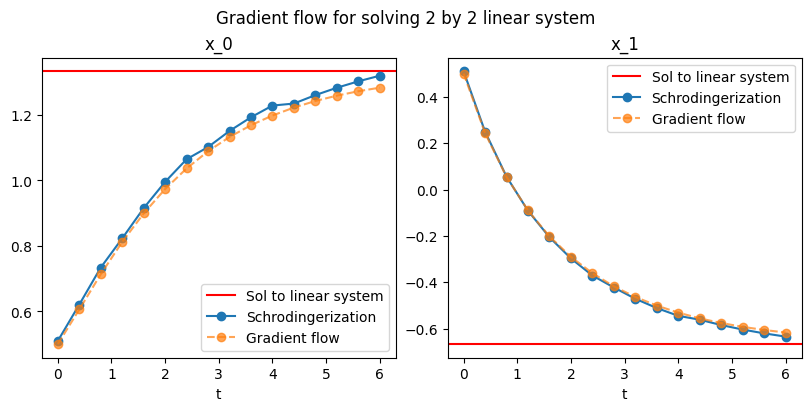

In [16]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(8,4))

aspect = 0.4

for i in range(2):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization")
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    
    axs[i].plot(t_vals, sol_gf.y[i], '--o', label="Gradient flow", alpha=0.7)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

Jacobi method

In [176]:
Lamb = A.diagonal()
M = A - diags(Lamb)
print(M.toarray())

C = vstack([diags((1 / Lamb)) @ hstack([-M, b]), hstack([csc_matrix((1, A.shape[0])), [1]])])
print((C - eye(dimension + 1)).toarray())
print(eigvals((C - eye(dimension + 1)).toarray()))

[[0.  0.5]
 [0.5 0. ]]
[[-1.  -0.5  1. ]
 [-0.5 -1.   0. ]
 [ 0.   0.   0. ]]
[-0.5+0.j -1.5+0.j  0. +0.j]


In [177]:
A_tilde.toarray()

array([[-1. , -0.5,  1. ],
       [-0.5, -1. ,  0. ],
       [ 0. ,  0. ,  0. ]])

In [178]:
F_jac = lambda t, u: (C - eye(A.shape[0] + 1)).toarray() @ u

t_vals = np.linspace(0, T, N_t)
sol_jac = solve_ivp(F_jac, [0, T], vstack([x_0, 1]).toarray().reshape(3), t_eval=t_vals)

In [179]:
u_recover = schrodingerization((C - eye(A.shape[0] + 1)), vstack([x_0, 1]), N, L, R, T, N_t, norm(b) / 2)

Eigvals of H1: [-1.58504324 -0.65555391  0.24059715]
H1: [[-1.  -0.5  0.5]
 [-0.5 -1.   0. ]
 [ 0.5  0.   0. ]]
H2: [[0.+0.j  0.+0.j  0.-0.5j]
 [0.+0.j  0.+0.j  0.+0.j ]
 [0.+0.5j 0.+0.j  0.+0.j ]]


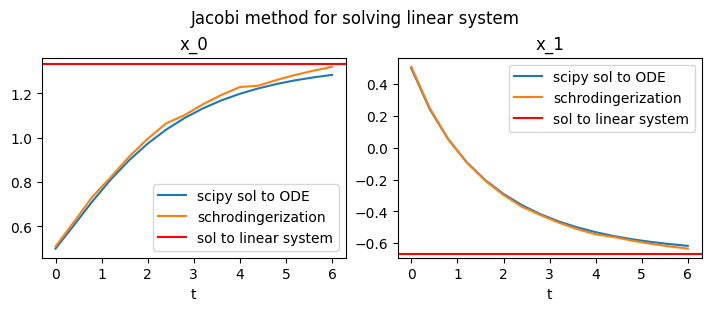

In [180]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, 2, constrained_layout=True, facecolor="white", figsize=(7,3))

aspect = 0.4

for i in range(2):
    axs[i].plot(t_vals, sol_jac.y[i], label="scipy sol to ODE")
    axs[i].plot(t_vals, u_recover[:,i].real, label="schrodingerization")
    
    axs[i].axhline(y=x_sol[i], color='red', label="sol to linear system")
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
plt.suptitle("Jacobi method for solving linear system")
plt.show()